# Olist Marketplace Performance & Customer Satisfaction Analysis
**Data Analyst Case Study — Operations & Customer Experience**

This notebook investigates what drives customer satisfaction on Olist's marketplace using order, item, payment, product, seller, customer, review, and geolocation data (Sept 2016 – Oct 2018).

In [20]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [29]:
orders = pd.read_csv('/content/Document from singhlink4 - orders.csv')
items = pd.read_csv('/content/Document from singhlink4 - order_items.csv')
payments = pd.read_csv('/content/Document from singhlink4 - order_payments.csv')
reviews = pd.read_csv('/content/Document from singhlink4 - order_reviews.csv')
customers = pd.read_csv('/content/Document from singhlink4 - customers.csv')
geo = pd.read_csv('/content/Document from singhlink4 - geolocation.csv')
products = pd.read_csv('/content/Document from singhlink4 - products.csv')
sellers = pd.read_csv('/content/Document from singhlink4 - sellers.csv')
trans = pd.read_csv('/content/Document from singhlink4 - category_translation.csv')


In [31]:
print("Order status distribution:")
print(orders['order_status'].value_counts())
print("\nDate range:", orders['order_purchase_timestamp'].min(), "to", orders['order_purchase_timestamp'].max())
print("\nMissing values in orders:")
print(orders.isnull().sum())

Order status distribution:
order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

Date range: 2016-09-04 21:15:19 to 2018-10-17 17:30:18

Missing values in orders:
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64


In [34]:
print("Review score distribution:")
print(reviews['review_score'].value_counts().sort_index())
print("\nDuplicate order_ids in reviews (multiple reviews per order):", reviews['order_id'].duplicated().sum())
print("Missing review_comment_message:", reviews['review_comment_message'].isnull().sum(), f"({reviews['review_comment_message'].isnull().mean()*100:.1f}%)")

Review score distribution:
review_score
1    11858
2     3235
3     8287
4    19200
5    57420
Name: count, dtype: int64

Duplicate order_ids in reviews (multiple reviews per order): 559
Missing review_comment_message: 58247 (58.2%)


In [33]:
print("Payment type distribution:")
print(payments['payment_type'].value_counts())
print("\nProducts missing category:", products['product_category_name'].isnull().sum())
print("Unique categories:", products['product_category_name'].nunique())

Payment type distribution:
payment_type
credit_card    76795
boleto         19784
voucher         5775
debit_card      1529
not_defined        3
Name: count, dtype: int64

Products missing category: 610
Unique categories: 73


## 2. Data Cleaning

Key decisions:
- **Reviews**: 559 orders have more than one review row. We keep the most recent review per order (by answer timestamp).
- **Delivered orders**: satisfaction/delivery analysis is restricted to orders with `order_status == 'delivered'`, since only these have real delivery dates and survey responses tied to an actual experience.
- **Time window**: Sept–Dec 2016 (4-324 orders/month) and Sep-Oct 2018 (4-16 orders/month) are onboarding/cutoff artifacts, not real seasonality. Time-trend analysis uses Jan 2017 - Aug 2018.
- **Category**: missing/untranslated category names are labeled 'unknown' rather than dropped, so those orders aren't lost from volume/revenue totals.

In [44]:
#DATA CLEANING
reviews_dedup = reviews.sort_values('review_answer_timestamp').drop_duplicates('order_id', keep='last')
print(f"Reviews before dedup: {len(reviews)}, after: {len(reviews_dedup)}")

item_agg = items.groupby('order_id').agg(
    n_items=('order_item_id','count'), total_price=('price','sum'),
    total_freight=('freight_value','sum'), n_sellers=('seller_id','nunique'),
    n_products=('product_id','nunique')).reset_index()

main_seller = items.sort_values('order_item_id').drop_duplicates('order_id')[['order_id','seller_id','product_id']]

pay_agg = payments.groupby('order_id').agg(
    total_payment=('payment_value','sum'), max_installments=('payment_installments','max'),
    n_payment_methods=('payment_type','nunique')).reset_index()

dom_pay = payments.sort_values('payment_value', ascending=False).drop_duplicates('order_id')[
    ['order_id','payment_type','payment_installments']]
if 'product_category_name_english' not in products.columns:
    products = products.merge(trans, on='product_category_name', how='left')
    products.rename(columns={'product_category_name_english': 'product_category_name'}, inplace=True)
products['category'] = products['product_category_name_english'].fillna(products['product_category_name']).fillna('unknown')

cust_geo = customers[['customer_id','customer_unique_id','customer_zip_code_prefix','customer_city','customer_state']]
sell_geo = sellers[['seller_id','seller_zip_code_prefix','seller_city','seller_state']]

master = orders.merge(cust_geo, on='customer_id', how='left')
master = master.merge(item_agg, on='order_id', how='left')
master = master.merge(main_seller, on='order_id', how='left')
master = master.merge(sell_geo, on='seller_id', how='left')
master = master.merge(products[['product_id','category']], on='product_id', how='left')
master = master.merge(pay_agg, on='order_id', how='left')
master = master.merge(dom_pay, on='order_id', how='left')
master = master.merge(reviews_dedup[['order_id','review_score','review_comment_message','review_creation_date']], on='order_id', how='left')

master['delivery_days'] = (master['order_delivered_customer_date'] - master['order_purchase_timestamp']).dt.days
master['estimated_days'] = (master['order_estimated_delivery_date'] - master['order_purchase_timestamp']).dt.days
master['delivery_delta'] = (master['order_delivered_customer_date'] - master['order_estimated_delivery_date']).dt.days
master['is_late'] = master['delivery_delta'] > 0
master['purchase_month'] = master['order_purchase_timestamp'].dt.to_period('M').astype(str)

print("Master table shape:", master.shape)

Reviews before dedup: 100000, after: 99441
Master table shape: (99441, 36)


In [45]:
delivered = master[master['order_status']=='delivered'].copy()
core = delivered[(delivered['purchase_month']>='2017-01') & (delivered['purchase_month']<='2018-08')].copy()
print("Delivered orders:", len(delivered))
print("Delivered orders with a matched review:", delivered['review_score'].notnull().sum())
print("Core time-window orders (2017-01 to 2018-08):", len(core))

Delivered orders: 96478
Delivered orders with a matched review: 96478
Core time-window orders (2017-01 to 2018-08): 96211


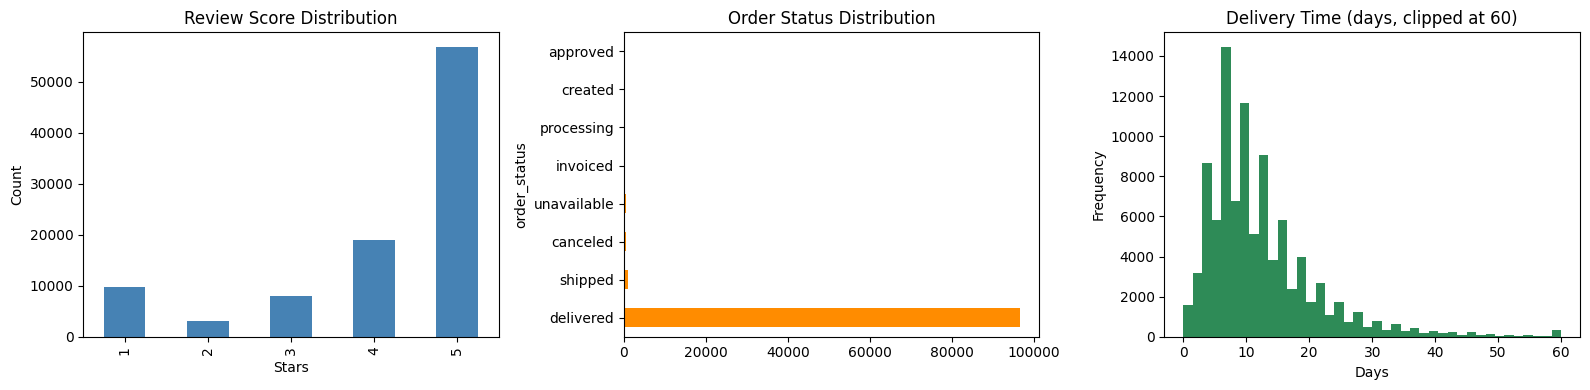

Review score summary statistic:
count    96478.000000
mean         4.142416
std          1.296475
min          1.000000
25%          4.000000
50%          5.000000
75%          5.000000
max          5.000000
Name: review_score, dtype: float64

% of orders that are 4-5 star: 78.5%
% of orders that are 1-2 star: 13.2%

Median delivery time: 10 days
% of orders delivered late vs estimate: 6.8%


In [47]:
#EXPLORATORY DATA ANALYSIS
fig, axes = plt.subplots(1, 3, figsize=(16,4))
delivered['review_score'].value_counts().sort_index().plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Review Score Distribution'); axes[0].set_xlabel('Stars'); axes[0].set_ylabel('Count')

orders['order_status'].value_counts().plot(kind='barh', ax=axes[1], color='darkorange')
axes[1].set_title('Order Status Distribution')

delivered['delivery_days'].clip(0,60).plot(kind='hist', bins=40, ax=axes[2], color='seagreen')
axes[2].set_title('Delivery Time (days, clipped at 60)'); axes[2].set_xlabel('Days')
plt.tight_layout(); plt.savefig('eda_overview.png', dpi=110); plt.show()

print("Review score summary statistic:")
print(delivered['review_score'].describe())
print(f"\n% of orders that are 4-5 star: {(delivered['review_score']>=4).mean()*100:.1f}%")
print(f"% of orders that are 1-2 star: {(delivered['review_score']<=2).mean()*100:.1f}%")
print(f"\nMedian delivery time: {delivered['delivery_days'].median():.0f} days")
print(f"% of orders delivered late vs estimate: {delivered['is_late'].mean()*100:.1f}%")

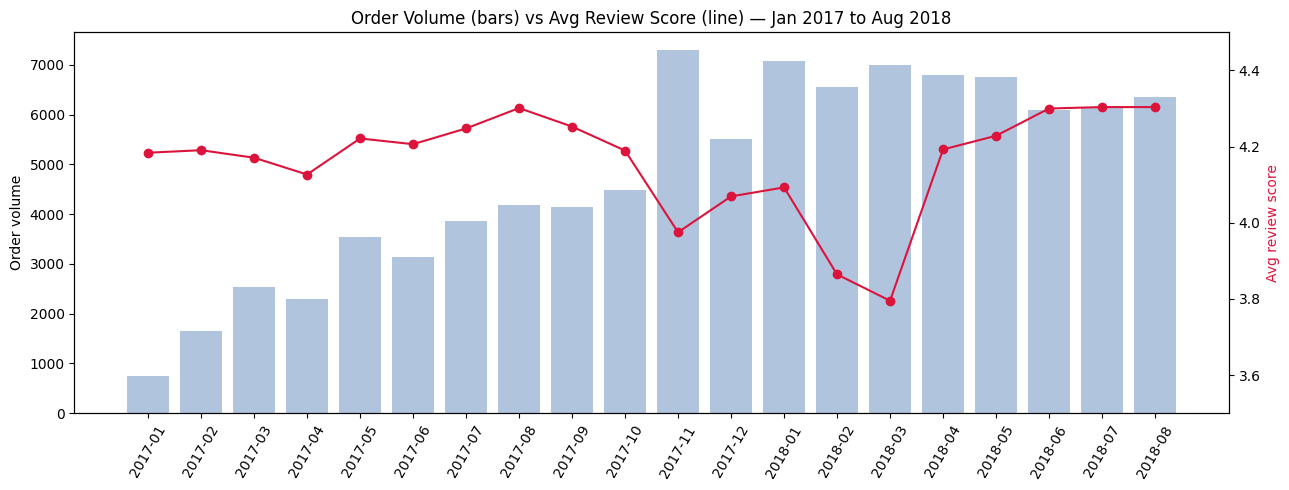

Order volume growth: 750 -> 6351 orders/month (747% growth)
Correlation of month-index with order volume: 0.89
Correlation of month-index with avg review score: -0.03

Lowest-review months:
   purchase_month  n_orders  avg_review   pct_late
14        2018-03      7003    3.795373  18.963301
13        2018-02      6555    3.864531  14.126621
10        2017-11      7289    3.975168  12.402250


In [50]:
#MARKETPLACE OVER TIME

monthly = core.groupby('purchase_month').agg(
    n_orders=('order_id','nunique'), revenue=('total_price','sum'),
    avg_review=('review_score','mean'), pct_late=('is_late','mean')).reset_index()
monthly['pct_late'] = monthly['pct_late']*100

fig, ax1 = plt.subplots(figsize=(13,5))
ax1.bar(monthly['purchase_month'], monthly['n_orders'], color='lightsteelblue', label='Order volume')
ax1.set_ylabel('Order volume'); ax1.tick_params(axis='x', rotation=60)
ax2 = ax1.twinx()
ax2.plot(monthly['purchase_month'], monthly['avg_review'], color='crimson', marker='o', label='Avg review score')
ax2.set_ylabel('Avg review score', color='crimson'); ax2.set_ylim(3.5, 4.5)
plt.title('Order Volume (bars) vs Avg Review Score (line) — Jan 2017 to Aug 2018')
fig.tight_layout(); plt.savefig('q1_trends.png', dpi=110); plt.show()

print(f"Order volume growth: {monthly['n_orders'].iloc[0]} -> {monthly['n_orders'].iloc[-1]} orders/month "
      f"({(monthly['n_orders'].iloc[-1]/monthly['n_orders'].iloc[0]-1)*100:.0f}% growth)")
print(f"Correlation of month-index with order volume: {np.corrcoef(range(len(monthly)), monthly['n_orders'])[0,1]:.2f}")
print(f"Correlation of month-index with avg review score: {np.corrcoef(range(len(monthly)), monthly['avg_review'])[0,1]:.2f}")
print("\nLowest-review months:")
print(monthly.nsmallest(3, 'avg_review')[['purchase_month','n_orders','avg_review','pct_late']])

**Finding:** Order volume grew ~8x over the period (steady growth, correlation 0.89 with time), but average review score did **not** trend upward with it (correlation ~0) — it hovers around 4.0-4.3 with sharp dips in Nov 2017 and Feb-Mar 2018 that coincide with spikes in late-delivery rate. Growth and satisfaction are decoupled, and satisfaction is fragile under demand surges.


/tmp/ipykernel_856/2752135830.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bucket_stats = d2.groupby('delay_bucket').agg(
/tmp/ipykernel_856/2752135830.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=bucket_stats, x='delay_bucket', y='avg_review', ax=ax, palette='RdYlGn_r' if False else 'coolwarm')


     delay_bucket      n  avg_review  pct_1star
0   7+ days early  76140    4.302561   6.712635
1  1-6 days early  12504    4.166827   7.445617
2         On time   1292    4.010062   9.133127
3   1-3 days late   1870    3.281818  25.347594
4   4-7 days late   1802    2.086570  59.100999
5    8+ days late   2862    1.690776  69.881202


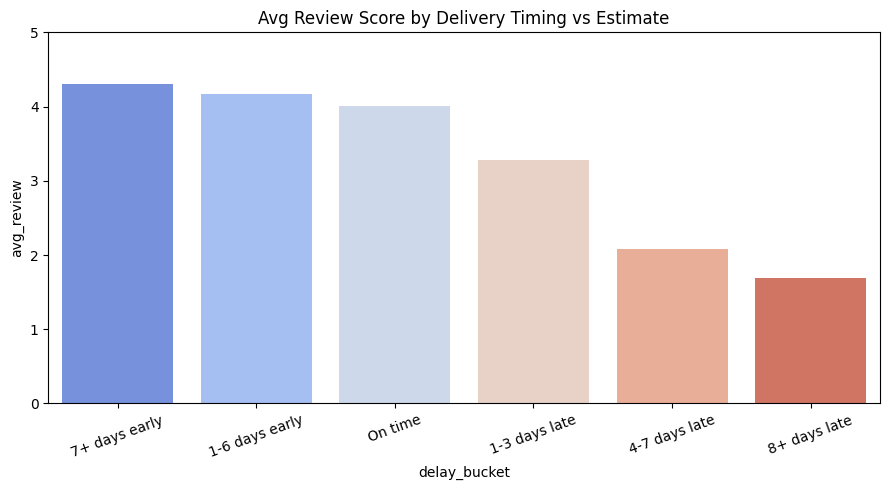


Overall late rate: 6.8%
Avg review if late: 2.26
Avg review if on-time: 4.28
Correlation delivery_delta vs review_score: -0.27


In [51]:
#DELIVERY PERFORMANCE AND CUSTOMER SATISFACTION

d2 = delivered.dropna(subset=['delivery_delta','review_score']).copy()

def bucket(d):
    if d <= -7:
      return '7+ days early'
    elif d <= -1:
      return '1-6 days early'
    elif d == 0:
      return 'On time'
    elif d <= 3:
      return '1-3 days late'
    elif d <= 7:
      return '4-7 days late'
    else:
      return '8+ days late'
order_labels = ['7+ days early','1-6 days early','On time','1-3 days late','4-7 days late','8+ days late']
d2['delay_bucket'] = pd.Categorical(d2['delivery_delta'].apply(bucket), categories=order_labels, ordered=True)

bucket_stats = d2.groupby('delay_bucket').agg(
    n=('order_id','count'), avg_review=('review_score','mean'),
    pct_1star=('review_score', lambda x: (x==1).mean()*100)).reset_index()
print(bucket_stats)

fig, ax = plt.subplots(figsize=(9,5))
sns.barplot(data=bucket_stats, x='delay_bucket', y='avg_review', ax=ax, palette='RdYlGn_r' if False else 'coolwarm')
ax.set_title('Avg Review Score by Delivery Timing vs Estimate'); ax.set_ylim(0,5)
plt.xticks(rotation=20); plt.tight_layout(); plt.savefig('q2_delay_buckets.png', dpi=110); plt.show()

print(f"\nOverall late rate: {d2['is_late'].mean()*100:.1f}%")
print(f"Avg review if late: {d2[d2['is_late']]['review_score'].mean():.2f}")
print(f"Avg review if on-time: {d2[~d2['is_late']]['review_score'].mean():.2f}")
print(f"Correlation delivery_delta vs review_score: {d2['delivery_delta'].corr(d2['review_score']):.2f}")

In [52]:
# Does the penalty hold across categories and states, or is it concentrated?
rows = []
for cat, grp in d2.groupby('category'):
    if grp['is_late'].sum() >= 20:
        rows.append({'category': cat, 'n': len(grp),
                      'ontime_avg': grp[~grp['is_late']]['review_score'].mean(),
                      'late_avg': grp[grp['is_late']]['review_score'].mean()})
cat_penalty = pd.DataFrame(rows)
cat_penalty['penalty'] = cat_penalty['ontime_avg'] - cat_penalty['late_avg']
print("Late-delivery penalty (stars lost) by category — min/median/max across categories with 20+ late orders:")
print(cat_penalty['penalty'].agg(['min','median','max']))

rows2 = []
for st, grp in d2.groupby('customer_state'):
    if grp['is_late'].sum() >= 20:
        rows2.append({'state': st, 'n': len(grp),
                       'ontime_avg': grp[~grp['is_late']]['review_score'].mean(),
                       'late_avg': grp[grp['is_late']]['review_score'].mean()})
state_penalty = pd.DataFrame(rows2)
state_penalty['penalty'] = state_penalty['ontime_avg'] - state_penalty['late_avg']
print("\nLate-delivery penalty by state — min/median/max across states with 20+ late orders:")
print(state_penalty['penalty'].agg(['min','median','max']))

Late-delivery penalty (stars lost) by category — min/median/max across categories with 20+ late orders:
min       1.347985
median    2.004808
max       2.498721
Name: penalty, dtype: float64

Late-delivery penalty by state — min/median/max across states with 20+ late orders:
min       1.488829
median    2.034749
max       2.624419
Name: penalty, dtype: float64


**Finding:** Average review score collapses as deliveries run later — from 4.30 (7+ days early) to 1.69 (8+ days late). Only 6.8% of orders arrive late, but the on-time-vs-late penalty (roughly 1.3-2.6 stars) holds in **every** category and **every** state tested — this is a universal driver, not a localized issue.

Sellers based in SP: 1764 of 2959 (60%)
Customers based in SP: 39149 of 93388 (42%)

Same-state vs cross-state shipping:
   same_state      n  avg_delivery_days  pct_late  avg_freight  avg_review
0       False  61765          14.684579  8.048247    26.908502    4.082118
1        True  34705           7.482409  4.503674    15.448560    4.249647


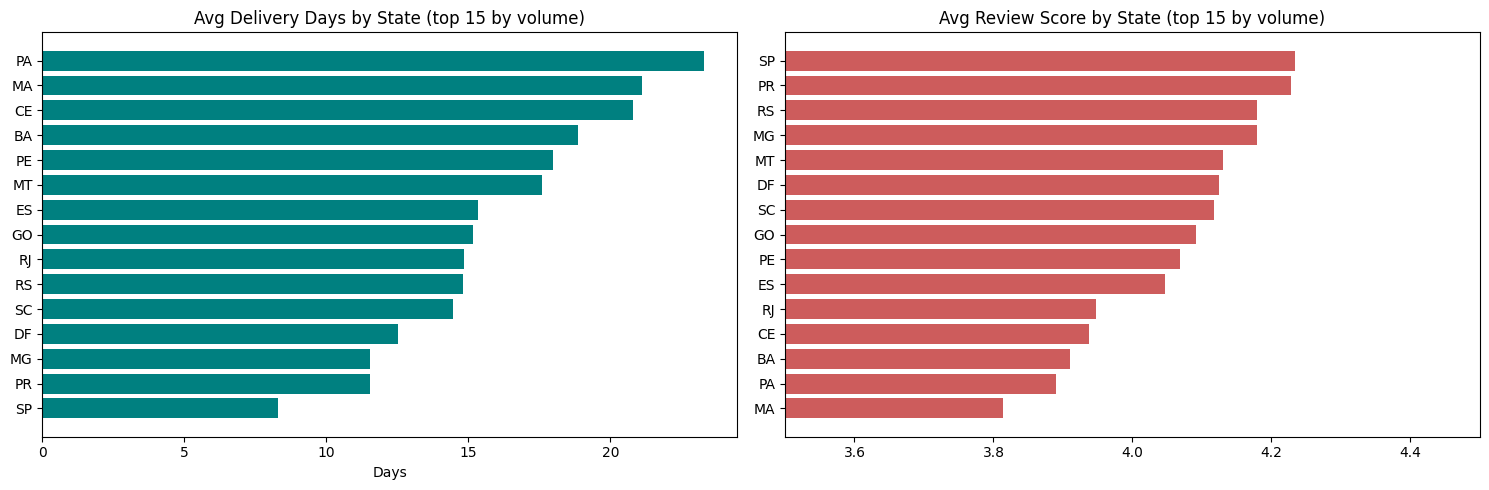


Worst-performing states (min 50 orders):
   customer_state      n  avg_delivery_days   pct_late  avg_review  \
9              MA    717          21.117155  17.433752    3.813110   
1              AL    397          24.040302  21.410579    3.826196   
13             PA    946          23.316068  11.205074    3.890063   
24             SE    335          21.029851  15.223881    3.898507   
4              BA   3256          18.866400  12.162162    3.910627   
5              CE   1279          20.817826  13.760751    3.937451   
18             RJ  12350          14.848583  12.105263    3.947045   
16             PI    476          18.993697  13.865546    3.978992   

    freight_pct_of_price  
9              26.317694  
1              19.423791  
13             21.523960  
24             24.242397  
4              19.764345  
5              21.241330  
18             16.807334  
16             24.146540  


In [53]:
#GEOLOCATIONS AND SELLERS PATTERN

sellers_by_state = d2.groupby('seller_state')['seller_id'].nunique().sort_values(ascending=False)
cust_by_state = d2.groupby('customer_state')['customer_unique_id'].nunique().sort_values(ascending=False)
print(f"Sellers based in SP: {sellers_by_state.get('SP',0)} of {sellers_by_state.sum()} ({sellers_by_state.get('SP',0)/sellers_by_state.sum()*100:.0f}%)")
print(f"Customers based in SP: {cust_by_state.get('SP',0)} of {cust_by_state.sum()} ({cust_by_state.get('SP',0)/cust_by_state.sum()*100:.0f}%)")

d2['same_state'] = d2['customer_state'] == d2['seller_state']
ss = d2.groupby('same_state').agg(n=('order_id','count'), avg_delivery_days=('delivery_days','mean'),
    pct_late=('is_late','mean'), avg_freight=('total_freight','mean'), avg_review=('review_score','mean')).reset_index()
ss['pct_late'] = ss['pct_late']*100
print("\nSame-state vs cross-state shipping:")
print(ss)

geo_state = d2.groupby('customer_state').agg(n=('order_id','count'), avg_freight=('total_freight','mean'),
    avg_price=('total_price','mean'), avg_delivery_days=('delivery_days','mean'),
    pct_late=('is_late','mean'), avg_review=('review_score','mean')).reset_index()
geo_state['pct_late'] = geo_state['pct_late']*100
geo_state['freight_pct_of_price'] = geo_state['avg_freight']/geo_state['avg_price']*100
geo_top = geo_state[geo_state['n']>=50].sort_values('avg_review')

fig, axes = plt.subplots(1, 2, figsize=(15,5))
top15 = geo_state.sort_values('n', ascending=False).head(15).sort_values('avg_delivery_days')
axes[0].barh(top15['customer_state'], top15['avg_delivery_days'], color='teal')
axes[0].set_title('Avg Delivery Days by State (top 15 by volume)'); axes[0].set_xlabel('Days')
axes[1].barh(top15.sort_values('avg_review')['customer_state'], top15.sort_values('avg_review')['avg_review'], color='indianred')
axes[1].set_title('Avg Review Score by State (top 15 by volume)'); axes[1].set_xlim(3.5,4.5)
plt.tight_layout(); plt.savefig('q3_geo.png', dpi=110); plt.show()

print("\nWorst-performing states (min 50 orders):")
print(geo_top.head(8)[['customer_state','n','avg_delivery_days','pct_late','avg_review','freight_pct_of_price']])

**Finding:** Sellers are heavily concentrated in São Paulo (~60% of sellers vs ~42% of customers). Cross-state shipments take almost 2x as long as same-state (14.7 vs 7.5 days) and are ~80% more likely to be late. Northeastern/Northern states (MA, AL, PA, SE, BA, CE, PI) see 11-21% late rates, 19-24 day average delivery, and freight eating 20-26% of order value — vs SP's 4.5% late rate, 8.3 days, 14% freight ratio. Reviews track this geography closely (SP: 4.23 vs MA/AL: ~3.8).

Platform avg review: 4.14 across 52 categories with >=100 orders



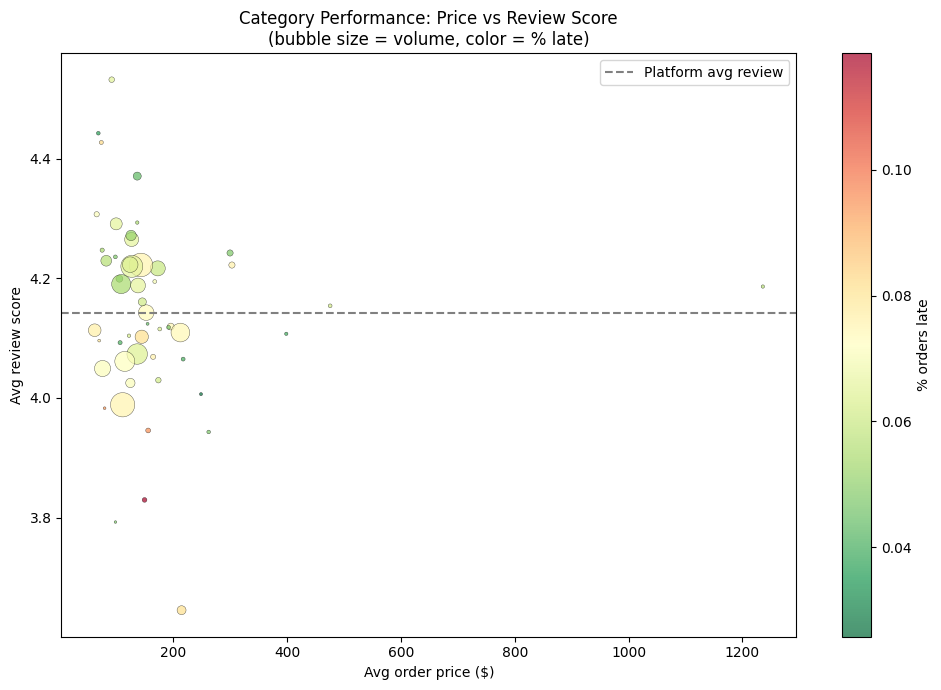

Best performing (min 100 orders):
                  category     n   avg_price  avg_review
8   books_general_interest   492   92.010671    4.532520
37              food_drink   219   68.463379    4.442922
10         books_technical   255   73.804510    4.427451
53     luggage_accessories  1013  136.880128    4.371175
36                    food   436   65.613280    4.307339

Worst performing (min 100 orders):
                 category     n   avg_price  avg_review  pct_late
57       office_furniture  1245  214.752675    3.644980  0.081124
30  fashion_male_clothing   106   98.606887    3.792453  0.047170
4                   audio   346  149.724277    3.829480  0.118497
34        fixed_telephony   211  262.368294    3.943128  0.047393
47           home_confort   368  156.060652    3.945652  0.095109


In [54]:
#PRODUCT CATEGORY PERFORMANCE

overall_avg_review = d2['review_score'].mean()
cat_stats = d2.groupby('category').agg(n=('order_id','count'), revenue=('total_price','sum'),
    avg_price=('total_price','mean'), avg_review=('review_score','mean'),
    pct_late=('is_late','mean')).reset_index()
sig_cats = cat_stats[cat_stats['n']>=100].copy()
print(f"Platform avg review: {overall_avg_review:.2f} across {len(sig_cats)} categories with >=100 orders\n")

fig, ax = plt.subplots(figsize=(10,7))
scatter = ax.scatter(sig_cats['avg_price'], sig_cats['avg_review'], s=sig_cats['n']/30,
                      c=sig_cats['pct_late'], cmap='RdYlGn_r', alpha=0.7, edgecolors='k', linewidths=0.3)
ax.axhline(overall_avg_review, color='gray', linestyle='--', label='Platform avg review')
ax.set_xlabel('Avg order price ($)'); ax.set_ylabel('Avg review score')
ax.set_title('Category Performance: Price vs Review Score\n(bubble size = volume, color = % late)')
plt.colorbar(scatter, label='% orders late'); ax.legend()
plt.tight_layout(); plt.savefig('q4_category.png', dpi=110); plt.show()

print("Best performing (min 100 orders):")
print(sig_cats.sort_values('avg_review', ascending=False).head(5)[['category','n','avg_price','avg_review']])
print("\nWorst performing (min 100 orders):")
print(sig_cats.sort_values('avg_review').head(5)[['category','n','avg_price','avg_review','pct_late']])

In [55]:
# Is the worst category's low score explained by lateness, or something else?
worst_cats = sig_cats.sort_values('avg_review').head(5)['category'].tolist()
print("Checking if worst categories' low scores are delivery-driven (on-time review avg vs platform avg):")
for cat in worst_cats:
    grp = d2[d2['category']==cat]
    ontime_avg = grp[~grp['is_late']]['review_score'].mean()
    print(f"  {cat:25s} on-time avg review = {ontime_avg:.2f}  (platform on-time avg = {d2[~d2['is_late']]['review_score'].mean():.2f})")

Checking if worst categories' low scores are delivery-driven (on-time review avg vs platform avg):
  office_furniture          on-time avg review = 3.76  (platform on-time avg = 4.28)
  fashion_male_clothing     on-time avg review = 3.89  (platform on-time avg = 4.28)
  audio                     on-time avg review = 4.11  (platform on-time avg = 4.28)
  fixed_telephony           on-time avg review = 4.04  (platform on-time avg = 4.28)
  home_confort              on-time avg review = 4.12  (platform on-time avg = 4.28)


**Finding:** Categories like books, food/drink, luggage, and stationery outperform (4.27-4.53), while office_furniture, audio, and fashion_male_clothing underperform (3.6-3.9). Most of the gap traces back to elevated late-delivery rates in those categories — **except office_furniture**, which scores below the platform's on-time average even when delivered on time, pointing to a product-fit/quality issue independent of shipping.

  payment_type      n  avg_order_value  avg_installments  avg_review
0       boleto  19191       144.334979          1.000000    4.142254
1  credit_card  72818       166.183931          3.547969    4.142149
2   debit_card   1483       140.267620          1.000000    4.230614
3      voucher   2977       114.864599          1.000000    4.106147

Credit card installments vs order value / review:
  inst_bucket      n   avg_value  avg_review  pct_late
0           1  23357  100.645415    4.208374  5.968232
1         2-3  22021  135.017854    4.135280  6.834385
2         4-6  15691  181.797414    4.113568  6.946657
3        7-10  11420  333.245349    4.066025  7.469352
4         11+    329  361.499271    3.905775  8.206687


/tmp/ipykernel_856/1824325251.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  inst_stats = cc.groupby('inst_bucket').agg(n=('order_id','count'), avg_value=('total_payment','mean'),


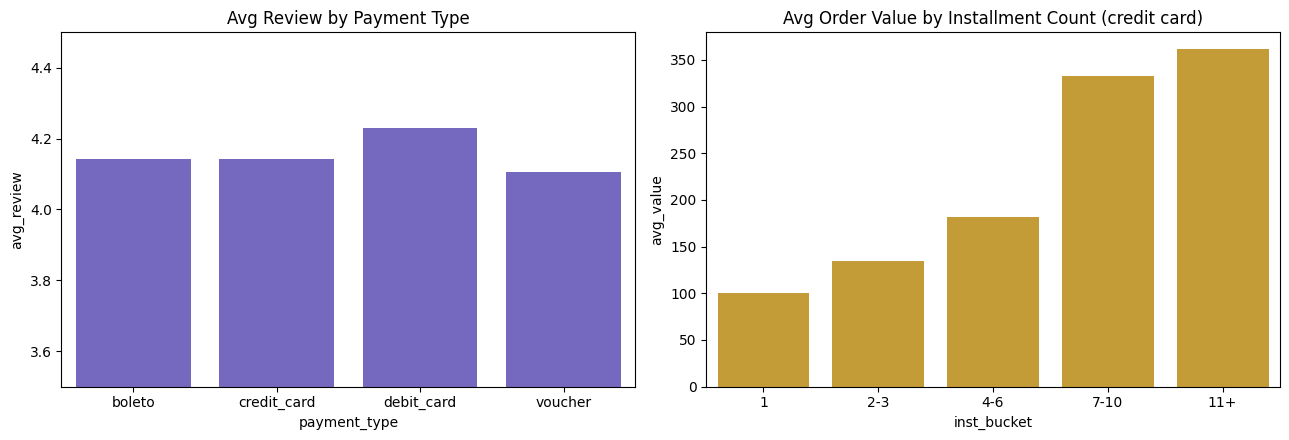


Correlation installments vs order value: 0.37
Correlation installments vs review score: -0.04


In [56]:
#PAYMENT BEHAVIOR

d2p = d2.dropna(subset=['payment_type'])
pay_stats = d2p.groupby('payment_type').agg(n=('order_id','count'), avg_order_value=('total_payment','mean'),
    avg_installments=('payment_installments','mean'), avg_review=('review_score','mean')).reset_index()
print(pay_stats)

cc = d2p[d2p['payment_type']=='credit_card'].copy()
def inst_bucket(i):
    if i==1: return '1'
    elif i<=3: return '2-3'
    elif i<=6: return '4-6'
    elif i<=10: return '7-10'
    else: return '11+'
cc['inst_bucket'] = pd.Categorical(cc['payment_installments'].apply(inst_bucket), categories=['1','2-3','4-6','7-10','11+'], ordered=True)
inst_stats = cc.groupby('inst_bucket').agg(n=('order_id','count'), avg_value=('total_payment','mean'),
    avg_review=('review_score','mean'), pct_late=('is_late','mean')).reset_index()
inst_stats['pct_late'] = inst_stats['pct_late']*100
print("\nCredit card installments vs order value / review:")
print(inst_stats)

fig, axes = plt.subplots(1,2, figsize=(13,4.5))
sns.barplot(data=pay_stats, x='payment_type', y='avg_review', ax=axes[0], color='slateblue')
axes[0].set_ylim(3.5,4.5); axes[0].set_title('Avg Review by Payment Type')
sns.barplot(data=inst_stats, x='inst_bucket', y='avg_value', ax=axes[1], color='goldenrod')
axes[1].set_title('Avg Order Value by Installment Count (credit card)')
plt.tight_layout(); plt.savefig('q5_payment.png', dpi=110); plt.show()

print(f"\nCorrelation installments vs order value: {cc['payment_installments'].corr(cc['total_payment']):.2f}")
print(f"Correlation installments vs review score: {cc['payment_installments'].corr(cc['review_score']):.2f}")

**Finding:** Payment *type* barely affects satisfaction (4.10-4.23 across all types). Installment count correlates with order value (r=0.37, larger purchases get split up) and shows a mild step-down in review score at high installment counts, partly tracking with slightly higher late rates on those bigger orders. Payment behavior is a minor, secondary factor at most.

Low-review rate in dataset: 13.2%


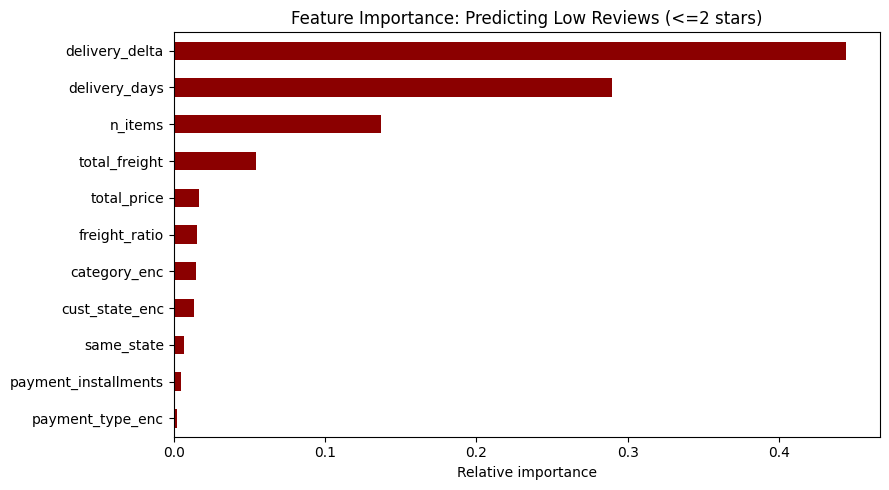

delivery_delta          0.444571
delivery_days           0.289742
n_items                 0.136675
total_freight           0.054445
total_price             0.016968
freight_ratio           0.015664
category_enc            0.014694
cust_state_enc          0.013418
same_state              0.006827
payment_installments    0.004952
payment_type_enc        0.002042
dtype: float64


In [57]:
#ROOT CAUSE ANALYSIS

from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder

rc = d2.dropna(subset=['review_score','delivery_delta','total_price','total_freight','payment_type','category']).copy()
rc['low_review'] = (rc['review_score']<=2).astype(int)
rc['freight_ratio'] = (rc['total_freight'] / rc['total_price'].replace(0,np.nan)).fillna(0)
rc['same_state'] = (rc['customer_state']==rc['seller_state']).astype(int)
rc['n_items'] = rc['n_items'].fillna(1)
rc['payment_installments'] = rc['payment_installments'].fillna(1)
rc['payment_type_enc'] = LabelEncoder().fit_transform(rc['payment_type'])
rc['category_enc'] = LabelEncoder().fit_transform(rc['category'].fillna('unknown'))
rc['cust_state_enc'] = LabelEncoder().fit_transform(rc['customer_state'])

cols = ['delivery_delta','delivery_days','total_price','total_freight','freight_ratio',
        'n_items','payment_installments','same_state','payment_type_enc','category_enc','cust_state_enc']
X, y = rc[cols], rc['low_review']
print(f"Low-review rate in dataset: {y.mean()*100:.1f}%")

rf = RandomForestClassifier(n_estimators=300, max_depth=8, min_samples_leaf=20, random_state=42, n_jobs=-1, class_weight='balanced')
rf.fit(X, y)
importances = pd.Series(rf.feature_importances_, index=cols).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9,5))
importances.plot(kind='barh', ax=ax, color='darkred'); ax.invert_yaxis()
ax.set_title('Feature Importance: Predicting Low Reviews (<=2 stars)'); ax.set_xlabel('Relative importance')
plt.tight_layout(); plt.savefig('q6_importance.png', dpi=110); plt.show()
print(importances)

In [58]:
# n_items effect, independent of delivery timing
nitems_stats = d2.dropna(subset=['n_items']).groupby('n_items').agg(
    n=('order_id','count'), avg_review=('review_score','mean'), pct_late=('is_late','mean')).reset_index()
print("Multi-item order effect (n_items = number of line items in the order):")
print(nitems_stats.head(6))

Multi-item order effect (n_items = number of line items in the order):
   n_items      n  avg_review  pct_late
0      1.0  86835    4.200967  0.069373
1      2.0   7392    3.668290  0.053707
2      3.0   1306    3.507657  0.049005
3      4.0    495    3.355556  0.046465
4      5.0    193    3.466321  0.046632
5      6.0    191    3.303665  0.083770


**Finding:** Delivery timing (delta + absolute days) accounts for ~73% of predictive importance for low reviews — by far the dominant driver. The next clearest signal is **order complexity**: multi-item orders average 3.67 stars vs 4.20 for single-item orders, and this is *not* explained by higher lateness (multi-item orders aren't more likely to be late) — likely partial fulfillment issues or one bad item dragging down the whole review. Freight cost/geography and category-specific quality (e.g. office_furniture) are secondary contributing factors. Payment behavior is negligible once delivery timing is controlled for.

793 sellers with 20+ delivered orders, out of 2959 total sellers
These 793 sellers account for 88% of delivered order volume

90 established sellers are underperforming (avg review < 3.8 or late rate > 15%):
                             seller_id state  n_orders  avg_review   pct_late  \
1475  7c67e1448b00f6e969d365cea6b010ab    SP       967    3.500517   9.203723   
276   1835b56ce799e6a4dc4eddc053f04066    SP       394    3.687817  10.913706   
79    06a2c3af7b3aee5d69171b0e14f0ee87    MA       389    3.992288  19.023136   
1319  70a12e78e608ac31179aea7f8422044b    SP       311    3.790997   9.324759   
1611  897060da8b9a21f655304d50fd935913    SP       301    3.704319  10.631229   
1601  88460e8ebdecbfecb5f9601833981930    PR       234    3.474359  17.948718   
2647  e5a3438891c0bfdb9394643f95273d8e    SP       215    3.981395  15.813953   
1316  7040e82f899a04d1b434b795a43b4617    SP       206    3.626214   7.766990   
537   2eb70248d66e0e3ef83659f71b244378    SP       186    2.752

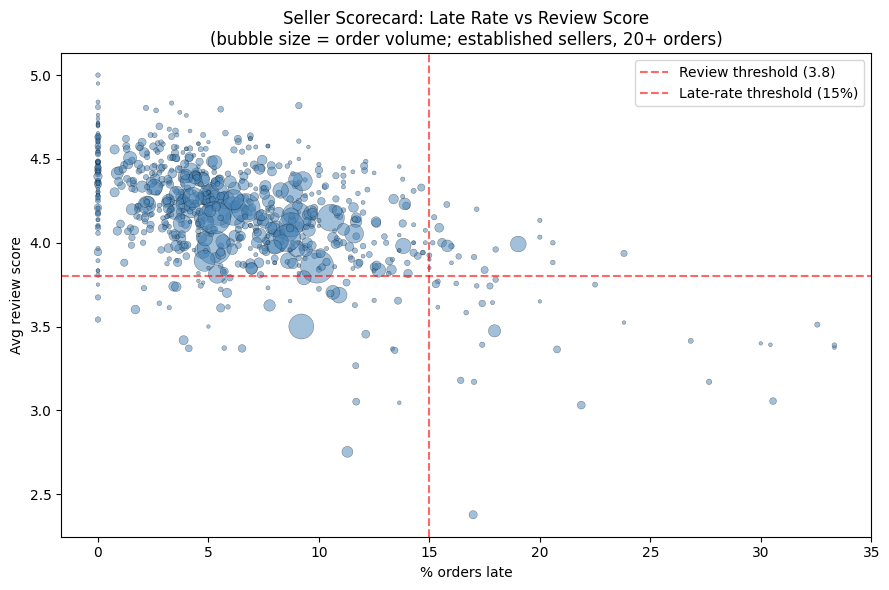

In [59]:
#SELLER PERFORMANCE SCORECARD

seller_scorecard = d2.dropna(subset=['seller_id']).groupby('seller_id').agg(
    n_orders=('order_id','count'), avg_review=('review_score','mean'),
    pct_late=('is_late','mean'), revenue=('total_price','sum'),
    state=('seller_state','first')).reset_index()
seller_scorecard['pct_late'] = seller_scorecard['pct_late']*100

# Focus on established sellers (20+ orders) to avoid small-sample noise
established = seller_scorecard[seller_scorecard['n_orders']>=20].copy()
print(f"{len(established)} sellers with 20+ delivered orders, out of {len(seller_scorecard)} total sellers")
print(f"These {len(established)} sellers account for {established['n_orders'].sum()/seller_scorecard['n_orders'].sum()*100:.0f}% of delivered order volume")

underperformers = established[(established['avg_review']<3.8) | (established['pct_late']>15)].sort_values('n_orders', ascending=False)
print(f"\n{len(underperformers)} established sellers are underperforming (avg review < 3.8 or late rate > 15%):")
print(underperformers.head(10)[['seller_id','state','n_orders','avg_review','pct_late','revenue']])
print(f"\nCombined revenue exposure from these underperforming sellers: ${underperformers['revenue'].sum():,.0f}")

fig, ax = plt.subplots(figsize=(9,6))
ax.scatter(established['pct_late'], established['avg_review'], s=established['n_orders']/3,
           alpha=0.5, color='steelblue', edgecolors='k', linewidths=0.3)
ax.axhline(3.8, color='red', linestyle='--', alpha=0.6, label='Review threshold (3.8)')
ax.axvline(15, color='red', linestyle='--', alpha=0.6, label='Late-rate threshold (15%)')
ax.set_xlabel('% orders late'); ax.set_ylabel('Avg review score')
ax.set_title('Seller Scorecard: Late Rate vs Review Score\n(bubble size = order volume; established sellers, 20+ orders)')
ax.legend()
plt.tight_layout(); plt.savefig('q_deepdive_sellers.png', dpi=110); plt.show()


### Summary of Findings

1. **Growth and satisfaction are decoupled.** Order volume grew ~8x from Jan 2017 to Aug 2018, but average review score stayed flat (~4.0-4.3) with sharp dips during demand surges (Nov 2017, Feb-Mar 2018) — satisfaction is not scaling with volume, and is fragile under load.
2. **Delivery timing is the dominant driver of satisfaction**, by a wide margin. Average review collapses from 4.30 (delivered early) to 1.69 (8+ days late). This ~2-star late-delivery penalty holds consistently across every state and category tested.
3. **Seller concentration in São Paulo creates a structural geographic penalty.** ~60% of sellers are based in SP vs ~42% of customers. Cross-state orders take ~2x longer and are far more likely to be late. Northeast/North states see 11-21% late rates and freight costs eating up to 26% of order value, and their review scores are correspondingly lower.
4. **Category performance mostly follows delivery performance**, with one notable exception: office_furniture underperforms even on on-time deliveries, suggesting a product-fit or quality issue distinct from logistics.
5. **Payment behavior is a minor factor.** Payment type has almost no relationship with satisfaction; installment count has a very mild negative association, likely reflecting order value and lateness rather than a distinct effect.
6. **Root cause ranking:** delivery timing (~73% of predictive importance) >> order complexity (multi-item orders average 3.67★ vs 4.20★, independent of lateness) > freight/geography > category-specific issues >> payment behavior (negligible).
7. **A specific, actionable seller list exists**: a subset of established sellers combine high late rates and low reviews, representing over $1M in revenue exposure and a concrete target for intervention.

### Recommendations

1. **Make on-time delivery the top operational KPI.** Given the size and universality of the late-delivery penalty, even small reductions in late-delivery rate should produce measurable satisfaction gains platform-wide.
2. **Build logistics capacity/redundancy for the Northeast and North regions** — recruit more regional sellers, negotiate better regional freight/logistics partnerships, or set more conservative (achievable) estimated delivery dates for these regions rather than overpromising.
3. **Add demand-surge planning** (e.g., around Black Friday) — proactively scale logistics capacity or adjust delivery estimates ahead of known high-volume periods to prevent the Nov 2017 / Feb-Mar 2018-style satisfaction crashes.
4. **Investigate office_furniture (and similarly-flagged categories) for product/listing quality**, separate from any delivery fixes.
5. **Launch a seller-performance program** targeting the identified underperforming established sellers — logistics support, coaching, or performance-based offboarding.
6. **Investigate multi-item order fulfillment** — partial shipments, mixed-seller orders, or quality-control processes for orders with 2+ line items, since this effect is independent of delivery timing.
print("Analysis complete.")